In [1]:
import pandas as pd

training_table = pd.read_parquet('/content/uber_trips_training.parquet')
testing_table = pd.read_parquet('/content/uber_trips_test.parquet')

print("Training table loaded. Head of the table:")
display(training_table.head())
print("\nTesting table loaded. Head of the table:")
display(testing_table.head())

Training table loaded. Head of the table:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,PU_avg_market_total_earnings_per_hour,DO_avg_market_total_earnings_per_hour,PU_trip_density_per_hour,DO_trip_density_per_hour,PU_zone_opportunity_score,DO_zone_opportunity_score,travel_penalty,net_gain
0,2,10,8,0,805.0,69.227329,859.841769,4.472050,48.371309,117.662456,3317.130280,15.480000,775.134440
1,2,10,15,4,1573.0,62.982835,704.553860,2.288620,42.443425,74.979061,2593.711105,27.520000,614.051025
2,2,10,16,3,2032.0,62.347841,688.789209,2.532536,43.111691,78.683976,2527.071843,35.191893,591.249474
3,2,10,17,2,1811.0,80.062613,604.634029,2.663707,38.049071,103.959339,2122.962694,40.275942,484.295474
4,2,10,18,3,1345.0,67.225116,610.723849,2.421796,35.518063,82.698026,2139.326920,25.116050,518.382682



Testing table loaded. Head of the table:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,PU_avg_market_total_earnings_per_hour,DO_avg_market_total_earnings_per_hour,PU_trip_density_per_hour,DO_trip_density_per_hour,PU_zone_opportunity_score,DO_zone_opportunity_score,travel_penalty,net_gain
0,2,39,17,0,1333.0,67.754914,1387.954591,1.600000,98.647725,64.740596,6330.069330,25.088139,1295.111538
1,2,39,17,4,1624.0,65.394089,1426.242904,2.216749,94.111871,76.404567,6429.824941,29.500000,1331.348815
2,2,39,18,1,1318.0,94.796439,1441.177206,4.272997,105.094787,157.608455,6643.555575,34.706030,1311.674737
3,2,39,18,2,1343.0,68.008929,1373.524527,2.678571,99.529997,88.583294,6275.134254,25.371109,1280.144490
4,2,45,16,5,4175.0,56.841198,889.556143,0.862275,34.848010,35.343806,3034.734338,65.920000,766.794946


### Install Required Packages

In [2]:
# Install necessary libraries
!pip install lightgbm scikit-learn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.1 MB/s eta 0:00:00


### Define Features and Target

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, ndcg_score

# Define the features for the model
features = [
    'PULocationID',
    'DOLocationID',
    'hour_bucket',
    'day_of_week_numeric',
    'average_PU_to_DO_time',
    # 'PU_avg_market_total_earnings_per_hour',
    # 'DO_avg_market_total_earnings_per_hour',
    # 'PU_trip_density_per_hour',
    # 'DO_trip_density_per_hour',
    # 'PU_zone_opportunity_score',
    # 'DO_zone_opportunity_score',
    # 'travel_penalty'
]

# Prepare training data
X_train = training_table[features]
y_train = training_table['net_gain']

# Prepare testing data
X_test = testing_table[features]
y_test = testing_table['net_gain']

print("Training features (X_train) head:")
display(X_train.head())
print("\nTraining target (y_train) head:")
display(y_train.head())
print("\nTesting features (X_test) head:")
display(X_test.head())
print("\nTesting target (y_test) head:")
display(y_test.head())

Training features (X_train) head:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time
0,2,10,8,0,805.0
1,2,10,15,4,1573.0
2,2,10,16,3,2032.0
3,2,10,17,2,1811.0
4,2,10,18,3,1345.0



Training target (y_train) head:


,net_gain
0,775.134440
1,614.051025
2,591.249474
3,484.295474
4,518.382682



Testing features (X_test) head:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time
0,2,39,17,0,1333.0
1,2,39,17,4,1624.0
2,2,39,18,1,1318.0
3,2,39,18,2,1343.0
4,2,45,16,5,4175.0



Testing target (y_test) head:


,net_gain
0,1295.111538
1,1331.348815
2,1311.674737
3,1280.144490
4,766.794946


### 1. Data Overview (Head)


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,PU_avg_market_total_earnings_per_hour,DO_avg_market_total_earnings_per_hour,PU_trip_density_per_hour,DO_trip_density_per_hour,PU_zone_opportunity_score,DO_zone_opportunity_score,travel_penalty,net_gain
0,2,10,8,0,805.0,69.227329,859.841769,4.472050,48.371309,117.662456,3317.130280,15.480000,775.134440
1,2,10,15,4,1573.0,62.982835,704.553860,2.288620,42.443425,74.979061,2593.711105,27.520000,614.051025
2,2,10,16,3,2032.0,62.347841,688.789209,2.532536,43.111691,78.683976,2527.071843,35.191893,591.249474
3,2,10,17,2,1811.0,80.062613,604.634029,2.663707,38.049071,103.959339,2122.962694,40.275942,484.295474
4,2,10,18,3,1345.0,67.225116,610.723849,2.421796,35.518063,82.698026,2139.326920,25.116050,518.382682



### 2. Data Information (Info)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3185960 entries, 0 to 3185959
Data columns (total 13 columns):
 #   Column                                 Dtype  
---  ------                                 -----  
 0   PULocationID                           int32  
 1   DOLocationID                           int32  
 2   hour_bucket                            int32  
 3   day_of_week_numeric                    int32  
 4   average_PU_to_DO_time                  float64
 5   PU_avg_market_total_earnings_per_hour  float64
 6   DO_avg_market_total_earnings_per_hour  float64
 7   PU_trip_density_per_hour               float64
 8   DO_trip_density_per_hour               float64
 9   PU_zone_opportunity_score              float64
 10  DO_zone_opportunity_score              float64
 11  travel_penalty                         float64
 12  net_gain                               float64
dtypes: float64(9), int32(4)
memory usage: 267.4 MB

### 3. Descriptive Sta

,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,PU_avg_market_total_earnings_per_hour,DO_avg_market_total_earnings_per_hour,PU_trip_density_per_hour,DO_trip_density_per_hour,PU_zone_opportunity_score,DO_zone_opportunity_score,travel_penalty,net_gain
count,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06,3.185960e+06
mean,1.368430e+02,1.364459e+02,1.246443e+01,3.145945e+00,1.569227e+03,1.006213e+03,9.480104e+02,5.284381e+01,5.026041e+01,4.247646e+03,2.898730e+03,4.722430e+02,-5.304454e+02
std,7.578188e+01,7.512441e+01,6.769279e+00,1.971388e+00,8.518062e+02,7.853370e+02,7.538513e+02,3.745267e+01,3.672093e+01,4.102510e+03,3.841671e+03,5.047472e+02,1.302147e+03
min,2.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.662959e+01,0.000000e+00,7.815892e-01,0.000000e+00,1.795524e+01,-2.573319e+04,0.000000e+00,-2.111699e+04
25%,7.200000e+01,7.200000e+01,7.000000e+00,1.000000e+00,9.820000e+02,4.633614e+02,4.213446e+02,2.635936e+01,2.412660e+01,1.538481e+03,5.240448e+02,1.444452e+02,-1.017736e+03
50%,1.400000e+02,1.380000e+02,1.300000e+01,3.000000e+00,1.446333e+03,8.150955e+02,7.640872e+02,4.504413e+01,4.291540e+01,3.126400e+03,1.932805e+03,3.166022e+02,-2.938096e+02
75%,2.050000e+02,2.020000e+02,1.800000e+01,5.000000e+00,2.016000e+03,1.324707e+03,1.275428e+03,6.950970e+01,6.730831e+01,5.613510e+03,4.246522e+03,6.252374e+02,1.219304e+02
max,2.630000e+02,2.630000e+02,2.300000e+01,6.000000e+00,3.489200e+04,1.028283e+04,1.028283e+04,3.515910e+02,3.515910e+02,6.031199e+04,6.031199e+04,1.207746e+04,1.001824e+04



### 4. Missing Values


,0
PULocationID,0
DOLocationID,0
hour_bucket,0
day_of_week_numeric,0
average_PU_to_DO_time,0
PU_avg_market_total_earnings_per_hour,0
DO_avg_market_total_earnings_per_hour,0
PU_trip_density_per_hour,0
DO_trip_density_per_hour,0
PU_zone_opportunity_score,0



### 5. Distribution of Numerical Features


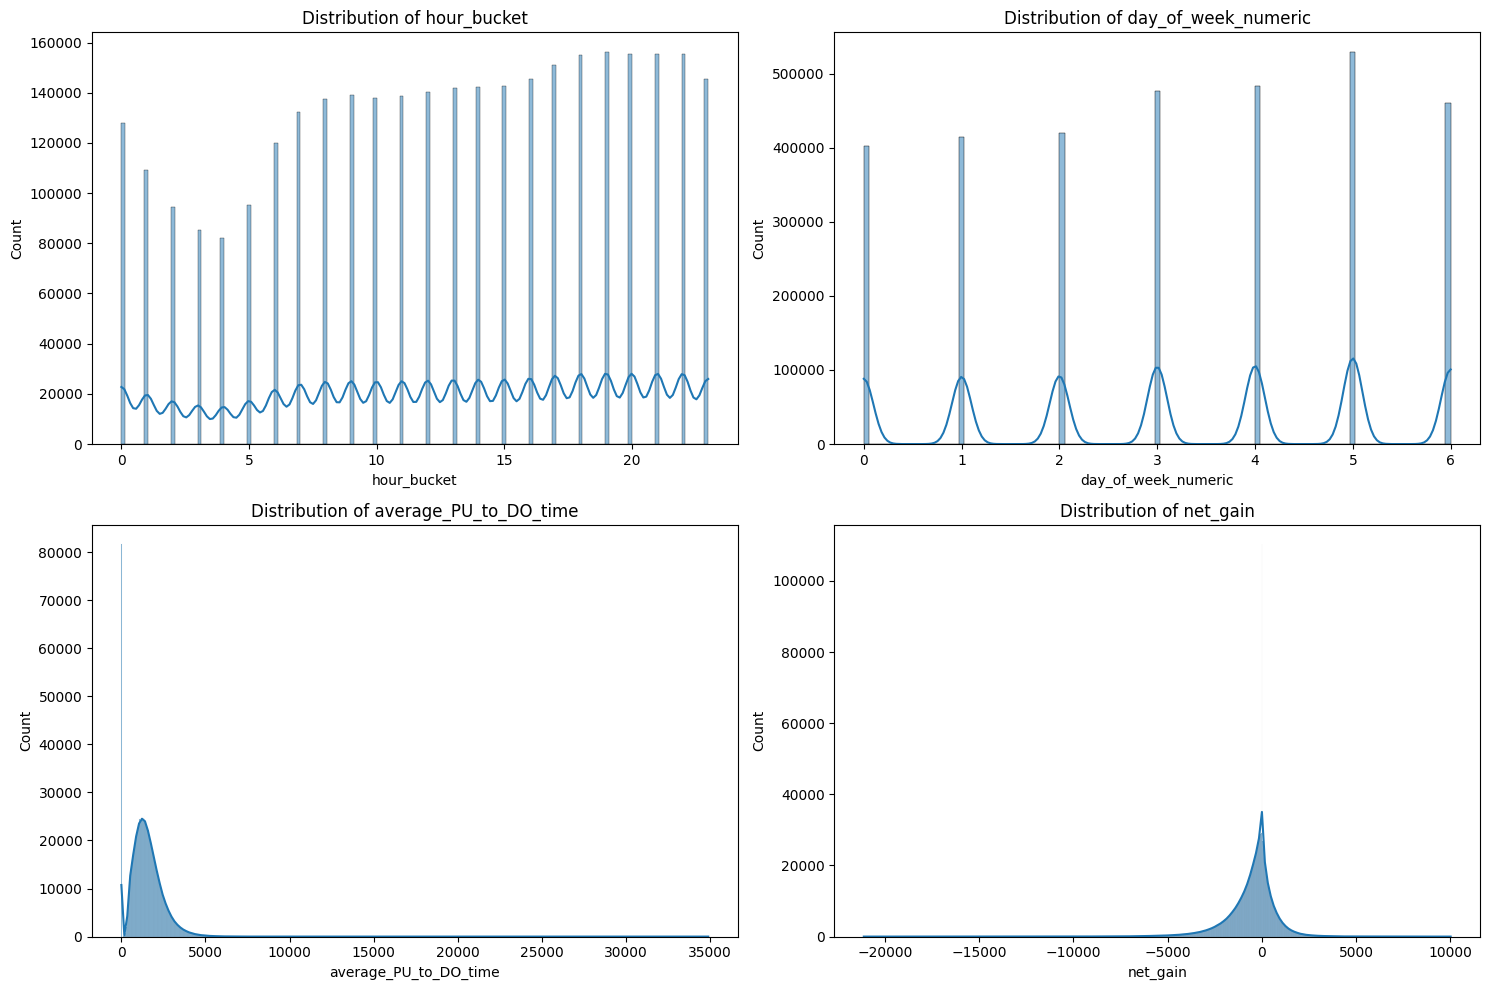


### 6. Value Counts for Categorical Features (Top 10 if many unique values)


/tmp/ipykernel_14014/2351200023.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.index, y=top_counts.values, palette='viridis')
/tmp/ipykernel_14014/2351200023.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_counts.index, y=top_counts.values, palette='viridis')


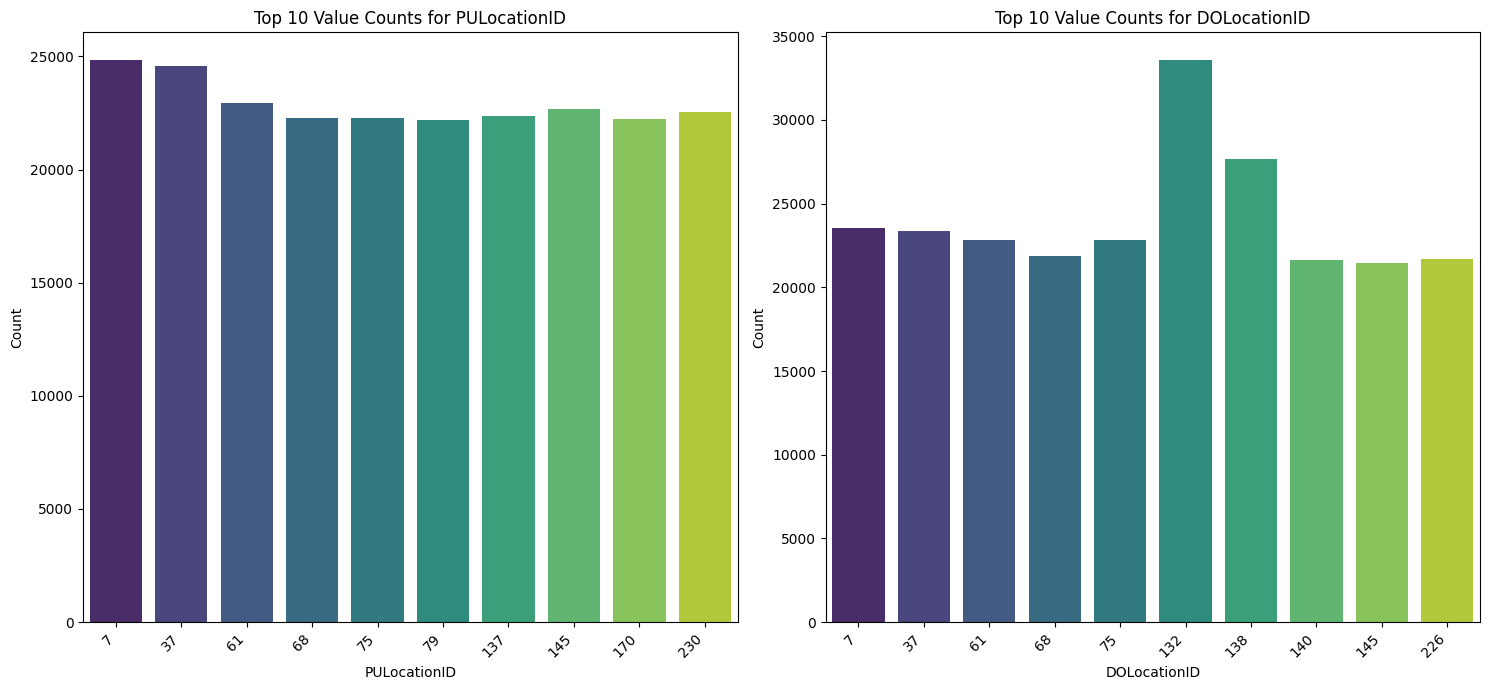


### 7. Correlation Matrix


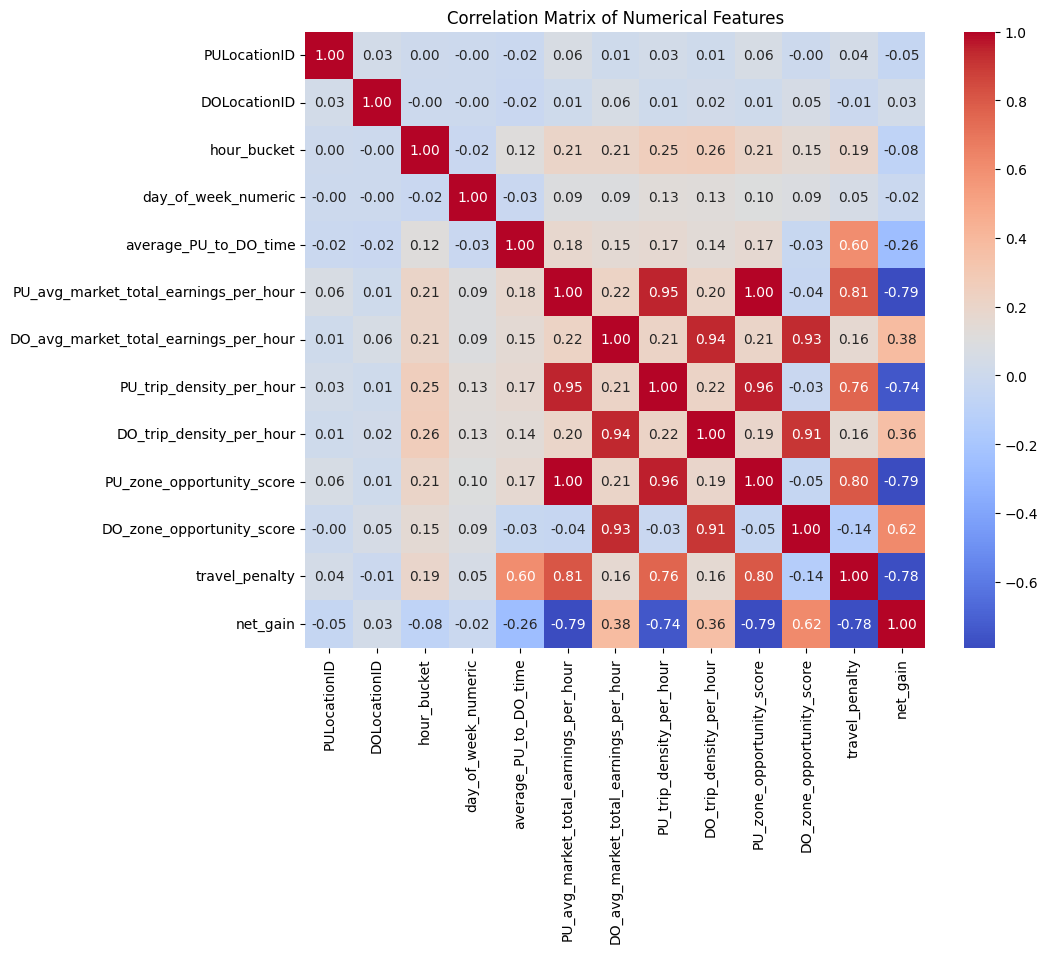

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### 1. Data Overview (Head)")
display(training_table.head())

print("\n### 2. Data Information (Info)")
training_table.info()

print("\n### 3. Descriptive Statistics (Describe)")
display(training_table.describe())

print("\n### 4. Missing Values")
display(training_table.isnull().sum().sort_values(ascending=False))

print("\n### 5. Distribution of Numerical Features")
# Select numerical columns for distribution plots
numerical_cols = training_table.select_dtypes(include=['number']).columns

# Exclude IDs and potentially other non-meaningful numerical features if they are high cardinality
# We'll focus on 'hour_bucket', 'day_of_week_numeric', 'average_PU_to_DO_time', and 'net_gain'

features_to_plot_num = [
    'hour_bucket',
    'day_of_week_numeric',
    'average_PU_to_DO_time',
    'net_gain'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot_num):
    if col in numerical_cols:
        plt.subplot(2, 2, i + 1)
        sns.histplot(training_table[col], kde=True)
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("\n### 6. Value Counts for Categorical Features (Top 10 if many unique values)")
# 'PULocationID' and 'DOLocationID' can be treated as categorical for analysis
features_to_plot_cat = [
    'PULocationID',
    'DOLocationID'
]

plt.figure(figsize=(15, 7))
for i, col in enumerate(features_to_plot_cat):
    plt.subplot(1, 2, i + 1)
    # Get top 10 value counts for better visualization if there are too many unique values
    top_counts = training_table[col].value_counts().head(10)
    sns.barplot(x=top_counts.index, y=top_counts.values, palette='viridis')
    plt.title(f'Top 10 Value Counts for {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n### 7. Correlation Matrix")
plt.figure(figsize=(10, 8))
sns.heatmap(training_table[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Baseline LightGBM Model Training

In [5]:
# Initialize and train a baseline LightGBM Regressor model
baseline_model = LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline LightGBM model trained successfully.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023156 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 3185960, number of used features: 5
[LightGBM] [Info] Start training from score -530.445441
Baseline LightGBM model trained successfully.


### Baseline Model Evaluation

In [6]:
# Make predictions on the testing data
y_pred_baseline = baseline_model.predict(X_test)

# Calculate regression metrics
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f'Baseline Model MAE: {mae_baseline:.4f}')
print(f'Baseline Model RMSE: {rmse_baseline:.4f}')
print(f'Baseline Model R²: {r2_baseline:.4f}')

# Calculate NDCG for ranking quality
ndcg_scores_baseline = []

# Group by trip context to calculate NDCG
for _, group in testing_table.groupby(['PULocationID', 'hour_bucket', 'day_of_week_numeric']):
    if len(group) > 1: # NDCG requires at least two items to rank
        true_relevance = group['net_gain'].values
        predicted_scores = y_pred_baseline[group.index]

        # Shift true_relevance to be non-negative if there are negative values for NDCG calculation
        min_true_score = np.min(true_relevance)
        if min_true_score < 0:
            true_relevance_shifted = true_relevance - min_true_score
        else:
            true_relevance_shifted = true_relevance

        # Ensure there are no NaN values in the scores before calculating NDCG
        if not np.isnan(true_relevance_shifted).any() and not np.isnan(predicted_scores).any():
            # Reshape for ndcg_score, which expects 2D arrays
            ndcg = ndcg_score([true_relevance_shifted], [predicted_scores])
            ndcg_scores_baseline.append(ndcg)

print(f'Average Baseline NDCG: {np.mean(ndcg_scores_baseline):.4f}' if ndcg_scores_baseline else 'Average Baseline NDCG: N/A (not enough groups with >1 item)')

Baseline Model MAE: 321.0431
Baseline Model RMSE: 467.5361
Baseline Model R²: 0.8818
Average Baseline NDCG: 0.9750


### Hyperparameter Tuning with Optuna

In [7]:
import optuna

def objective(trial):
    # Define hyperparameters to tune
    params = {
        'objective': 'regression',
        'n_estimators': trial.suggest_int('n_estimators', 300, 1200, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100, step=10),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100, step=10),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0, step=0.1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0, step=0.1),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1 # Use all available cores
    }

    model = LGBMRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return rmse

# Create an Optuna study and optimize
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=3, show_progress_bar=True)

print("Optuna optimization complete.")
print(f"Best trial:")
print(f"  Value: {study.best_value:.4f}")
print(f"  Params: ")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

[I 2026-05-04 18:22:11,179] A new study created in memory with name: no-name-387f29a2-8ec5-4ebf-a56a-72bc5b4e24b9


  0%|          | 0/3 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 3185960, number of used features: 5
[LightGBM] [Info] Start training from score -530.445441
[I 2026-05-04 18:23:15,477] Trial 0 finished with value: 594.3651437178336 and parameters: {'n_estimators': 900, 'learning_rate': 0.03765181418732552, 'num_leaves': 20, 'max_depth': 13, 'min_child_samples': 70, 'subsample': 0.7, 'colsample_bytree': 0.8999999999999999, 'reg_alpha': 5.919698257073897, 'reg_lambda': 0.1719905984070618}. Best is trial 0 with value: 594.3651437178336.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `forc

### Final Model Training with Tuned Hyperparameters

In [8]:
# Train the final model using the best hyperparameters found by Optuna
final_model = LGBMRegressor(**study.best_params)
final_model.fit(X_train, y_train)

print("Final LightGBM model trained with optimized hyperparameters.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022426 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 747
[LightGBM] [Info] Number of data points in the train set: 3185960, number of used features: 5
[LightGBM] [Info] Start training from score -530.445441
Final LightGBM model trained with optimized hyperparameters.


### Final Model Evaluation

In [9]:
# Make predictions on the testing data using the final model
y_pred_final = final_model.predict(X_test)

# Calculate regression metrics
mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print(f'Final Model MAE: {mae_final:.4f}')
print(f'Final Model RMSE: {rmse_final:.4f}')
print(f'Final Model R²: {r2_final:.4f}')

# Calculate NDCG for ranking quality
ndcg_scores_final = []

for _, group in testing_table.groupby(['PULocationID', 'hour_bucket', 'day_of_week_numeric']):
    if len(group) > 1:
        true_relevance = group['net_gain'].values
        predicted_scores = y_pred_final[group.index]

        min_true_score = np.min(true_relevance)
        if min_true_score < 0:
            true_relevance_shifted = true_relevance - min_true_score
        else:
            true_relevance_shifted = true_relevance

        if not np.isnan(true_relevance_shifted).any() and not np.isnan(predicted_scores).any():
            ndcg = ndcg_score([true_relevance_shifted], [predicted_scores])
            ndcg_scores_final.append(ndcg)

print(f'Average Final NDCG: {np.mean(ndcg_scores_final):.4f}' if ndcg_scores_final else 'Average Final NDCG: N/A (not enough groups with >1 item)')

Final Model MAE: 317.4087
Final Model RMSE: 460.4430
Final Model R²: 0.8854
Average Final NDCG: 0.9749


### Feature Importance

Feature Importances:


,feature,importance
0,PULocationID,14863
2,hour_bucket,12204
1,DOLocationID,9541
3,day_of_week_numeric,7182
4,average_PU_to_DO_time,4510


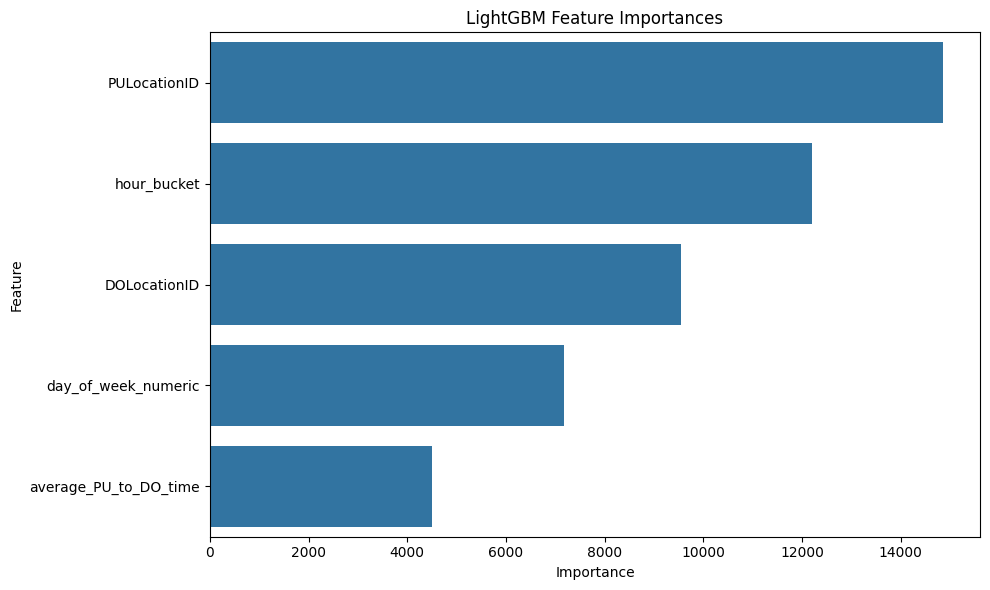

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the final model
importance_df = pd.DataFrame({
    'feature': features,
    'importance': final_model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values('importance', ascending=False)

print("Feature Importances:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('LightGBM Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Custom Relocation Zone Ranking Logic

In [11]:
def get_top_relocation_candidates(model, data_row, original_df, num_closest=9):
    # Extract current trip context (PU location, hour, day of week)
    current_pu_id = data_row['PULocationID']
    current_hour = data_row['hour_bucket']
    current_day = data_row['day_of_week_numeric']

    # Filter original_df to find relevant PU-DO pairs for the current context
    context_df = original_df[
        (original_df['PULocationID'] == current_pu_id) &
        (original_df['hour_bucket'] == current_hour) &
        (original_df['day_of_week_numeric'] == current_day)
    ].copy()

    # Get unique DOLocationIDs and their average_PU_to_DO_time for the context
    # Consider only distinct PU-DO pairs to avoid duplicates and simplify 'closest'
    unique_pu_do_pairs = context_df[['PULocationID', 'DOLocationID', 'average_PU_to_DO_time']].drop_duplicates()

    # Sort by average_PU_to_DO_time to find the closest 9 unique DOLocationIDs
    closest_candidates = unique_pu_do_pairs.sort_values('average_PU_to_DO_time').head(num_closest)

    # Prepare candidate rows for prediction
    candidate_data = []
    seen_do_locations = set()

    # Add the top 9 closest DO locations
    for _, row in closest_candidates.iterrows():
        do_id = row['DOLocationID']
        if do_id not in seen_do_locations:
            temp_row = data_row.copy()
            temp_row['DOLocationID'] = do_id
            # Ensure average_PU_to_DO_time is specific to the selected PU-DO pair
            temp_row['average_PU_to_DO_time'] = row['average_PU_to_DO_time']
            candidate_data.append(temp_row[features]) # Ensure only feature columns are selected
            seen_do_locations.add(do_id)

    # Add the 10th candidate: PU_zone itself (PULocationID == DOLocationID)
    if current_pu_id not in seen_do_locations:
        pu_as_do_row = data_row.copy()
        pu_as_do_row['DOLocationID'] = current_pu_id
        # For PU_zone itself, average_PU_to_DO_time is 0
        pu_as_do_row['average_PU_to_DO_time'] = 0.0 # Assuming 0 time for staying in the same zone
        candidate_data.append(pu_as_do_row[features])

    # Convert list of Series to DataFrame for prediction
    if not candidate_data:
        return pd.DataFrame(columns=features + ['predicted_net_gain'])

    candidates_df = pd.DataFrame(candidate_data)

    # Predict net_gain for all candidates
    candidates_df['predicted_net_gain'] = model.predict(candidates_df[features])

    # Rank candidates by predicted net_gain (highest first)
    ranked_candidates = candidates_df.sort_values('predicted_net_gain', ascending=False).reset_index(drop=True)

    return ranked_candidates

print("Function `get_top_relocation_candidates` defined.")

Function `get_top_relocation_candidates` defined.


### Example Relocation Recommendation

In [12]:
# Select a sample trip from the testing table to demonstrate the ranking
sample_trip = X_test.iloc[[533]].copy() # Take the first row as an example

print("Sample trip context for recommendation:")
display(sample_trip)

# Get relocation recommendations
recommendations = get_top_relocation_candidates(final_model, sample_trip.iloc[0], training_table)

print("\nTop 10 Relocation Zone Recommendations based on Predicted Net Gain:")
display(recommendations)

Sample trip context for recommendation:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time
533,3,20,15,6,785.142857



Top 10 Relocation Zone Recommendations based on Predicted Net Gain:


,PULocationID,DOLocationID,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,predicted_net_gain
0,3.0,242.0,15.0,6.0,588.833333,301.578400
1,3.0,51.0,15.0,6.0,529.243243,209.249117
2,3.0,185.0,15.0,6.0,563.066667,158.968885
3,3.0,208.0,15.0,6.0,624.181818,151.643252
4,3.0,81.0,15.0,6.0,462.069767,61.026610
5,3.0,3.0,15.0,6.0,0.000000,52.333378
6,3.0,183.0,15.0,6.0,476.200000,-75.470322
7,3.0,32.0,15.0,6.0,423.312500,-98.985774
8,3.0,184.0,15.0,6.0,475.000000,-114.904837


In [14]:
import pandas as pd

# Load the taxi zone lookup table
zone_lookup = pd.read_csv('/content/taxi_zone_lookup.csv')

# Define your custom inputs here. Feel free to change these values!
custom_inputs = {
    'PULocationID': 38,  # Example: 132 is JFK Airport
    'hour_bucket': 14,    # Example: 2 PM
    'day_of_week_numeric': 2, # Example: Wednesday
}

# Convert to a Series to match the expected input format of the function
custom_sample_trip = pd.Series(custom_inputs)

print("Custom trip context for recommendation:")
context_df = pd.DataFrame([custom_inputs])
# Add readable PU name to context
context_df = context_df.merge(zone_lookup[['LocationID', 'Borough', 'Zone']], left_on='PULocationID', right_on='LocationID', how='left').drop(columns=['LocationID'])
display(context_df)

# Get relocation recommendations using the custom input
custom_recommendations = get_top_relocation_candidates(
    model=final_model,
    data_row=custom_sample_trip,
    original_df=training_table
)

# --- Added logic for potential market earnings ---
# Look up the average market earnings for the candidate zones from testing_table
# FIXED: Use groupby and mean() to ensure only one earnings value per DOLocationID is returned
earnings_lookup = testing_table[
    (testing_table['hour_bucket'] == custom_inputs['hour_bucket']) &
    (testing_table['day_of_week_numeric'] == custom_inputs['day_of_week_numeric'])
].groupby('DOLocationID')['DO_avg_market_total_earnings_per_hour'].mean().reset_index()

# Merge earnings into recommendations
custom_recommendations = custom_recommendations.merge(earnings_lookup, on='DOLocationID', how='left')

# Calculate potential market earnings factoring in travel time (average_PU_to_DO_time in seconds)
# We assume they can earn the hourly rate for the remainder of the hour after traveling
custom_recommendations['potential_market_earnings'] = custom_recommendations['DO_avg_market_total_earnings_per_hour'] * (1 - (custom_recommendations['average_PU_to_DO_time'] / 3600.0))

# Floor at 0 in case travel time is > 1 hour
custom_recommendations['potential_market_earnings'] = custom_recommendations['potential_market_earnings'].clip(lower=0)
# -----------------------------------------------

# --- Added logic for readable zone names ---
# Map Pickup Zone Names
custom_recommendations = custom_recommendations.merge(
    zone_lookup[['LocationID', 'Borough', 'Zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
).rename(columns={'Borough': 'PU_Borough', 'Zone': 'PU_Zone'}).drop(columns=['LocationID'])

# Map Dropoff Zone Names
custom_recommendations = custom_recommendations.merge(
    zone_lookup[['LocationID', 'Borough', 'Zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
).rename(columns={'Borough': 'DO_Borough', 'Zone': 'DO_Zone'}).drop(columns=['LocationID'])

# Reorder columns for easier reading
ordered_cols = [
    'PU_Zone',
    'DO_Zone',
    'hour_bucket', 'day_of_week_numeric', 'average_PU_to_DO_time',
    'predicted_net_gain', 'DO_avg_market_total_earnings_per_hour',
    'potential_market_earnings'
]
custom_recommendations = custom_recommendations[[c for c in ordered_cols if c in custom_recommendations.columns]]
# -----------------------------------------------

# Remove any remaining duplicate rows just in case
custom_recommendations = custom_recommendations.drop_duplicates()

print("\nTop 10 Relocation Zone Recommendations based on Custom Input:")
display(custom_recommendations)

Custom trip context for recommendation:


,PULocationID,hour_bucket,day_of_week_numeric,Borough,Zone
0,38,14,2,Queens,Cambria Heights



Top 10 Relocation Zone Recommendations based on Custom Input:


,PU_Zone,DO_Zone,hour_bucket,day_of_week_numeric,average_PU_to_DO_time,predicted_net_gain,DO_avg_market_total_earnings_per_hour,potential_market_earnings
0,Cambria Heights,Saint Albans,14.0,2.0,635.320000,221.850919,849.202133,699.336828
1,Cambria Heights,Hollis,14.0,2.0,570.000000,90.062346,314.032399,264.310602
2,Cambria Heights,Bellerose,14.0,2.0,942.000000,86.426094,360.398140,266.093960
3,Cambria Heights,Queens Village,14.0,2.0,494.600000,80.198401,723.068173,623.726640
4,Cambria Heights,Springfield Gardens South,14.0,2.0,665.000000,73.886686,536.843299,437.676412
5,Cambria Heights,Springfield Gardens North,14.0,2.0,826.000000,59.487740,566.687735,436.664383
6,Cambria Heights,Cambria Heights,14.0,2.0,0.000000,37.715478,291.046095,291.046095
7,Cambria Heights,Rosedale,14.0,2.0,837.750000,3.486581,369.464237,283.486830
8,Cambria Heights,Laurelton,14.0,2.0,451.619048,-39.659052,419.632000,366.989276


--- Model Impact Analysis (Market Earnings): Simulated on 42367 Random Contexts ---
Average Baseline Earnings (Staying): $747.67/hr
Average Potential Earnings (Following Recommendation): $1389.63/hr
Average Absolute Lift per Relocation: +$641.96/hr
Average Percentage Lift: +85.86%



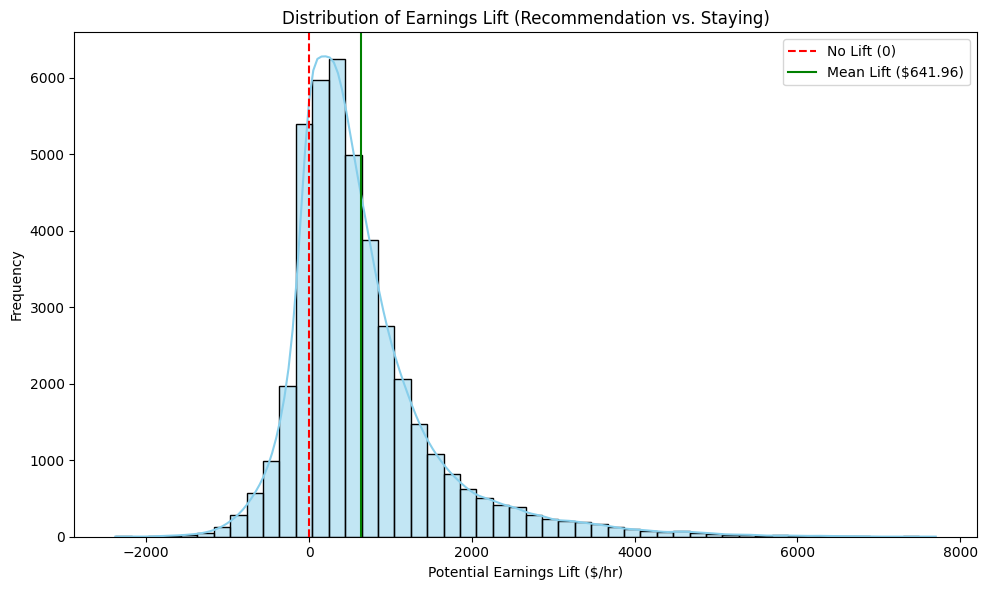

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Attach our model's predictions to the testing dataset
eval_df = testing_table.copy()
eval_df['predicted_net_gain'] = y_pred_final

# 2. Define contexts to sample from (unique combinations of Pickup, Hour, Day)
context_cols = ['PULocationID', 'hour_bucket', 'day_of_week_numeric']

# We only want contexts where a "Stay" option is available in the testing data for a fair comparison
# (Stay = where Dropoff Location is the same as Pickup Location)
stay_rows = eval_df[eval_df['PULocationID'] == eval_df['DOLocationID']]
valid_contexts = stay_rows[context_cols].drop_duplicates()

# 3. Sample up to 10,000 random contexts
num_samples = min(100000, len(valid_contexts))
sampled_contexts = valid_contexts.sample(n=num_samples, random_state=42)

# Filter the evaluation dataframe to only these sampled contexts
sampled_eval_df = eval_df.merge(sampled_contexts, on=context_cols)

# 4. Extract the Baseline Outcomes if the driver 'Stayed' (No relocation)
stay_actuals = sampled_eval_df[sampled_eval_df['PULocationID'] == sampled_eval_df['DOLocationID']].copy()
# For staying, travel time is ~0, so potential earnings = DO_avg_market_total_earnings_per_hour
stay_actuals = stay_actuals[context_cols + ['DO_avg_market_total_earnings_per_hour']].rename(
    columns={'DO_avg_market_total_earnings_per_hour': 'baseline_earnings'})
# Remove duplicates by taking the mean
stay_actuals = stay_actuals.groupby(context_cols)['baseline_earnings'].mean().reset_index()

# 5. Extract the Recommended Outcomes if the driver followed the 'Model Recommendation'
# Find the row with the maximum predicted_net_gain for each context
recommended_rows = sampled_eval_df.sort_values('predicted_net_gain', ascending=False).drop_duplicates(subset=context_cols, keep='first').copy()

# Calculate potential market earnings (accounting for travel time)
recommended_rows['potential_market_earnings'] = recommended_rows['DO_avg_market_total_earnings_per_hour'] * (1 - (recommended_rows['average_PU_to_DO_time'] / 3600.0))
# Floor at 0 in case travel time is > 1 hour
recommended_rows['potential_market_earnings'] = recommended_rows['potential_market_earnings'].clip(lower=0)

recommended_actuals = recommended_rows[context_cols + ['DOLocationID', 'potential_market_earnings']]
recommended_actuals = recommended_actuals.rename(columns={'DOLocationID': 'rec_DO_zone'})

# 6. Combine and Compare
comparison_df = stay_actuals.merge(recommended_actuals, on=context_cols)
comparison_df['earnings_lift'] = comparison_df['potential_market_earnings'] - comparison_df['baseline_earnings']

# 7. Summary Statistics
mean_stay = comparison_df['baseline_earnings'].mean()
mean_rec = comparison_df['potential_market_earnings'].mean()
mean_lift = comparison_df['earnings_lift'].mean()
# Calculate % lift safely
percent_lift = (mean_lift / abs(mean_stay)) * 100 if mean_stay != 0 else 0

print(f"--- Model Impact Analysis (Market Earnings): Simulated on {num_samples} Random Contexts ---")
print(f"Average Baseline Earnings (Staying): ${mean_stay:.2f}/hr")
print(f"Average Potential Earnings (Following Recommendation): ${mean_rec:.2f}/hr")
print(f"Average Absolute Lift per Relocation: +${mean_lift:.2f}/hr")
print(f"Average Percentage Lift: +{percent_lift:.2f}%\n")

# 8. Visualizing the distribution of Lift
plt.figure(figsize=(10, 6))
sns.histplot(comparison_df['earnings_lift'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Earnings Lift (Recommendation vs. Staying)')
plt.xlabel('Potential Earnings Lift ($/hr)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='r', linestyle='--', label='No Lift (0)')
plt.axvline(x=mean_lift, color='g', linestyle='-', label=f'Mean Lift (${mean_lift:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

The X-axis (Bottom): This represents the Earnings Lift in dollars per hour. It's the difference between what the driver could make by moving to the recommended zone versus what they would make by staying put.
The Y-axis (Side): This shows the Frequency, or how many times out of our simulated scenarios that specific dollar amount occurred.
**The Red Dashed Line ($0):** This is the "break-even" point. If a recommendation falls exactly on this line, moving to the new zone makes the exact same amount of money as staying. * **The Green Solid Line (Mean Lift):** This represents the overall average extra earnings across all simulated scenarios (around +$$0):** This is the "break-even" point. If a recommendation falls exactly on this line, moving to the new zone makes the exact same amount of money as staying. * **The Green Solid Line (Mean Lift):** This represents the overall average extra earnings across all simulated scenarios (around +$630 to +$640/hr based on the previous runs).
The Blue Shape (The Distribution): Notice how almost the entire blue mountain is positioned to the right of the red dashed line. This visually proves that in the vast majority of situations, following the model's recommendation results in a positive financial gain. The small sliver to the left of the red line represents the rare cases where staying put would have actually been slightly better (perhaps because the travel time to the new zone ate up the potential profits).

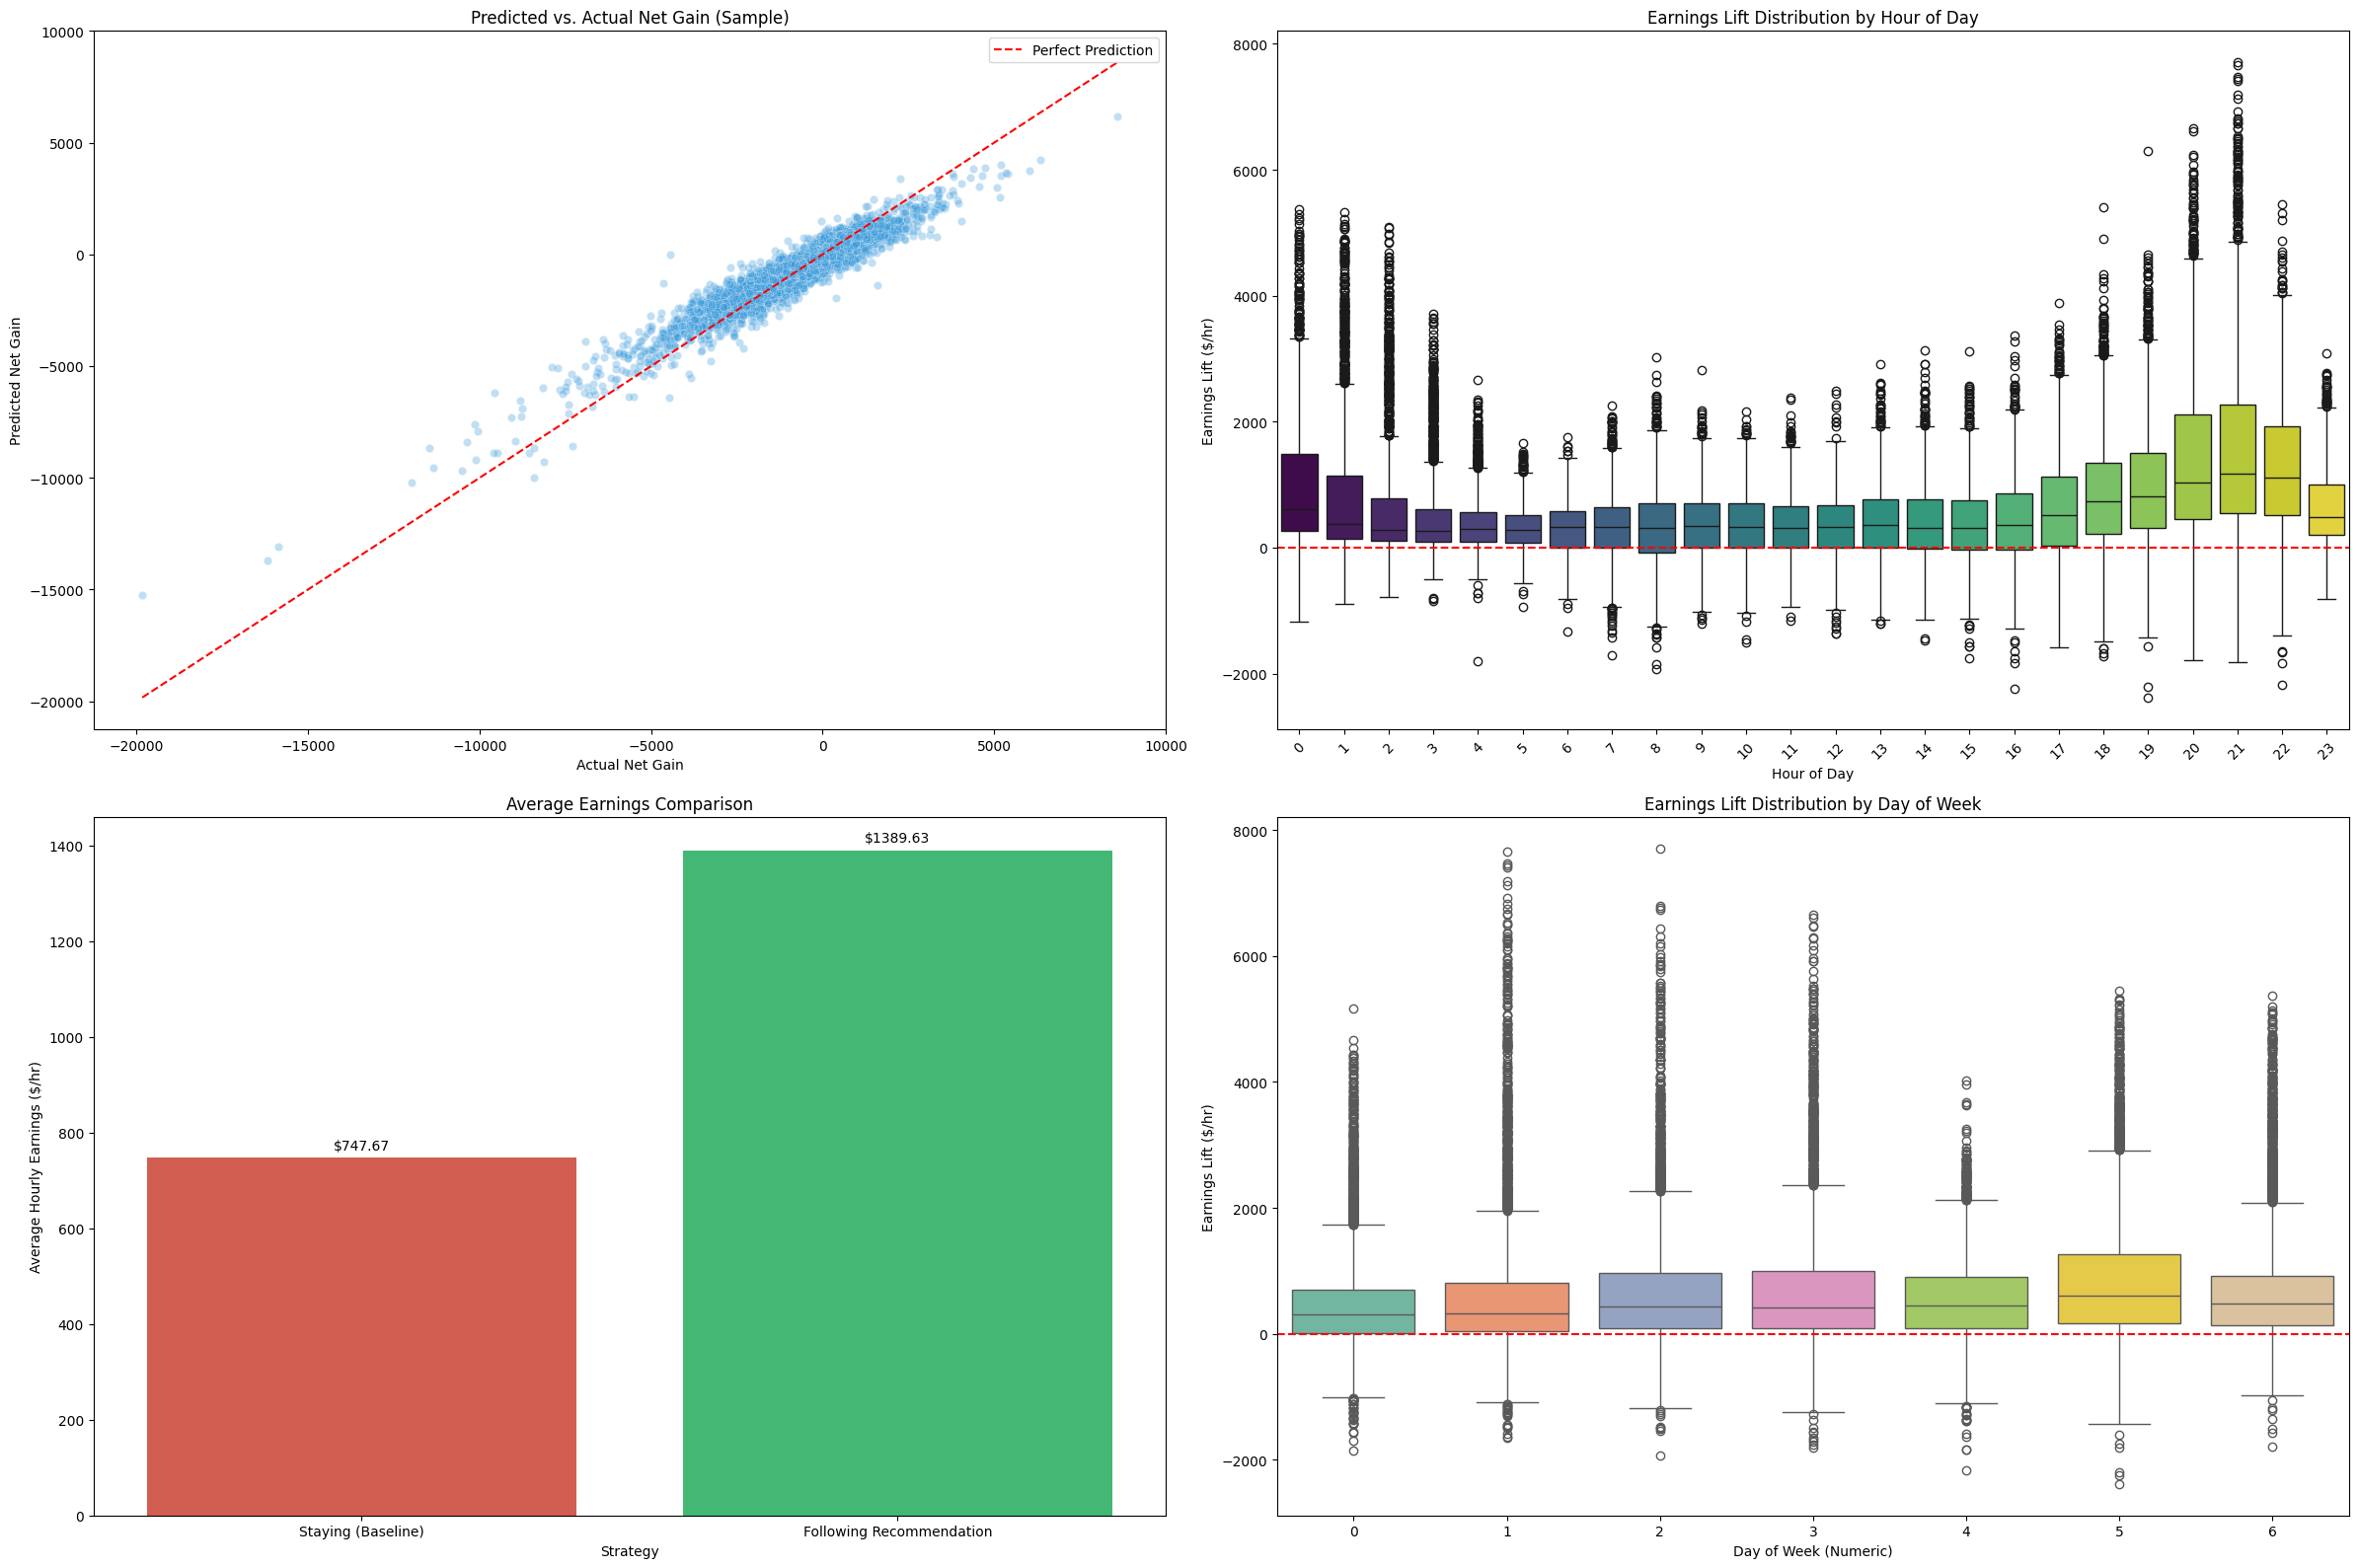

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set up the figure with multiple subplots in a 2x2 grid for larger individual charts
fig, axes = plt.subplots(2, 2, figsize=(24, 16))
axes = axes.flatten() # Flatten so we can still index them 0 through 3

# 1. Scatter Plot: Predicted vs Actual (Sampled for performance)
# Sampling 10,000 points to avoid overplotting
sample_indices = np.random.choice(len(y_test), min(10000, len(y_test)), replace=False)
sns.scatterplot(x=y_test.iloc[sample_indices], y=y_pred_final[sample_indices], alpha=0.3, ax=axes[0], color='#3498db')

# Add a diagonal line representing perfect predictions
min_val = min(y_test.iloc[sample_indices].min(), y_pred_final[sample_indices].min())
max_val = max(y_test.iloc[sample_indices].max(), y_pred_final[sample_indices].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
axes[0].set_title('Predicted vs. Actual Net Gain (Sample)')
axes[0].set_xlabel('Actual Net Gain')
axes[0].set_ylabel('Predicted Net Gain')
axes[0].legend()

# 2. Boxplot: Earnings Lift by Hour of Day
sns.boxplot(x='hour_bucket', y='earnings_lift', data=comparison_df, ax=axes[1], palette='viridis', hue='hour_bucket', legend=False)
axes[1].axhline(0, color='r', linestyle='--', label='No Lift (0)')
axes[1].set_title('Earnings Lift Distribution by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Earnings Lift ($/hr)')
# Rotate x labels if it gets too crowded
axes[1].tick_params(axis='x', rotation=45)

# 3. Bar Chart: Average Baseline vs Recommended Earnings
avg_earnings = pd.DataFrame({
    'Strategy': ['Staying (Baseline)', 'Following Recommendation'],
    'Average Earnings ($/hr)': [
        comparison_df['baseline_earnings'].mean(),
        comparison_df['potential_market_earnings'].mean()
    ]
})
sns.barplot(x='Strategy', y='Average Earnings ($/hr)', data=avg_earnings, ax=axes[2], palette=['#e74c3c', '#2ecc71'], hue='Strategy', legend=False)
axes[2].set_title('Average Earnings Comparison')
axes[2].set_ylabel('Average Hourly Earnings ($/hr)')

# Add value labels on top of the bars
for i, p in enumerate(axes[2].patches):
    axes[2].annotate(f'${p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points')

# 4. Boxplot: Earnings Lift by Day of Week
sns.boxplot(x='day_of_week_numeric', y='earnings_lift', data=comparison_df, ax=axes[3], palette='Set2', hue='day_of_week_numeric', legend=False)
axes[3].axhline(0, color='r', linestyle='--', label='No Lift (0)')
axes[3].set_title('Earnings Lift Distribution by Day of Week')
axes[3].set_xlabel('Day of Week (Numeric)')
axes[3].set_ylabel('Earnings Lift ($/hr)')

plt.tight_layout()
plt.show()


Predicted vs. Actual Scatter Plot: Shows how well the model's predictions align with reality.
Earnings Lift by Hour Boxplot: Shows when the model's recommendations provide the biggest financial boost throughout the day.
Average Earnings Bar Chart: A direct comparison of the average hourly earnings between staying put and following the recommendation.

## LightGBM Training + Hyperparameter Tuning + Evaluation

This section outlines a full pipeline using LightGBM to:

*   Train the relocation ranking model
*   Tune hyperparameters
*   Evaluate metrics
*   Measure ranking quality

### Strong Capstone Metrics

Aim for:

| Metric        | Strong Result |
| :------------ | :------------ |
| RMSE          | Low relative to earnings |
| R²            | >0.60         |
| NDCG          | >0.80         |
| Earnings Lift | +10–30%       |

In [17]:
import joblib

# Define the filename for the exported model
model_filename = 'relocation_model.pkl'

# Save the final_model using joblib
joblib.dump(final_model, model_filename)

print(f"Model successfully exported to '{model_filename}'")

Model successfully exported to 'relocation_model.pkl'
